<a href="https://colab.research.google.com/github/jrmhalzona/H3101-MLml-linear-algebra-project-Team-ML-4/blob/main/Milestone%201/Preprocessing%20Code/finmark_preprocessing_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the original raw datasets
demo_raw = pd.read_csv("customer_demographics_contaminated.csv")
trans_raw = pd.read_csv("customer_transactions_contaminated.csv")
social_raw = pd.read_csv("social_media_interactions_contaminated.csv")

print("Raw datasets loaded successfully.")
print("Demographics:", demo_raw.shape)
print("Transactions:", trans_raw.shape)
print("Social Media:", social_raw.shape)

Raw datasets loaded successfully.
Demographics: (3200, 6)
Transactions: (3200, 6)
Social Media: (3200, 6)


In [121]:
# Check structure, data types, missing values, and duplicate rows

for name, df in {
    "Demographics": demo_raw,
    "Transactions": trans_raw,
    "Social Media": social_raw
}.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nDuplicate rows:", df.duplicated().sum())


Demographics

Columns:
['CustomerID', 'Age', 'Gender', 'Location', 'IncomeLevel', 'SignupDate']

Data types:
CustomerID     object
Age            object
Gender         object
Location       object
IncomeLevel    object
SignupDate     object
dtype: object

Missing values:
CustomerID       0
Age            291
Gender           0
Location         0
IncomeLevel    303
SignupDate       0
dtype: int64

Duplicate rows: 177

Transactions

Columns:
['CustomerID', 'TransactionID', 'TransactionDate', 'Amount', 'ProductCategory', 'PaymentMethod']

Data types:
CustomerID         object
TransactionID      object
TransactionDate    object
Amount             object
ProductCategory    object
PaymentMethod      object
dtype: object

Missing values:
CustomerID           0
TransactionID        0
TransactionDate      0
Amount             304
ProductCategory    299
PaymentMethod        0
dtype: int64

Duplicate rows: 185

Social Media

Columns:
['CustomerID', 'InteractionID', 'InteractionDate', 'Platform',

In [122]:
# Load the finalized cleaned datasets

demo_final = pd.read_csv("finmark_customer_demographics_cleaned_final.csv")
trans_final = pd.read_csv("finmark_customer_transactions_cleaned_final.csv")
social_final = pd.read_csv("finmark_social_media_interactions_cleaned_final.csv")

print("Final cleaned datasets loaded successfully.")

print("\nDemographics:", demo_final.shape)
print("Transactions:", trans_final.shape)
print("Social Media:", social_final.shape)

Final cleaned datasets loaded successfully.

Demographics: (3023, 6)
Transactions: (3015, 6)
Social Media: (3020, 6)


In [123]:
# Verify the final cleaned datasets

for name, df in {
    "Demographics": demo_final,
    "Transactions": trans_final,
    "Social Media": social_final
}.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Rows and columns:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Total missing values:", df.isna().sum().sum())

    print("\nData types:")
    print(df.dtypes)


Demographics
Rows and columns: (3023, 6)
Duplicate rows: 0
Total missing values: 0

Data types:
CustomerID      object
Age            float64
Gender          object
Location        object
IncomeLevel     object
SignupDate      object
dtype: object

Transactions
Rows and columns: (3015, 6)
Duplicate rows: 0
Total missing values: 0

Data types:
CustomerID          object
TransactionID       object
TransactionDate     object
Amount             float64
ProductCategory     object
PaymentMethod       object
dtype: object

Social Media
Rows and columns: (3020, 6)
Duplicate rows: 0
Total missing values: 0

Data types:
CustomerID         object
InteractionID      object
InteractionDate    object
Platform           object
InteractionType    object
Sentiment          object
dtype: object


In [125]:
# Descriptive statistics for the finalized datasets

# Demographics - Age
age = demo_final["Age"]

# Transactions - Amount
amount = trans_final["Amount"]

print("=" * 60)
print("DEMOGRAPHICS - AGE")
print("=" * 60)
print("Mean:", age.mean())
print("Median:", age.median())
print("Mode:", age.mode().tolist())
print("Minimum:", age.min())
print("Maximum:", age.max())
print("Range:", age.max() - age.min())
print("Variance:", age.var())
print("Standard deviation:", age.std())

print("\n" + "=" * 60)
print("TRANSACTIONS - AMOUNT")
print("=" * 60)
print("Mean:", amount.mean())
print("Median:", amount.median())
print("Mode:", amount.mode().tolist())
print("Minimum:", amount.min())
print("Maximum:", amount.max())
print("Range:", amount.max() - amount.min())
print("Variance:", amount.var())
print("Standard deviation:", amount.std())

DEMOGRAPHICS - AGE
Mean: 44.688719814753554
Median: 45.0
Mode: [45.0]
Minimum: 18.0
Maximum: 70.0
Range: 52.0
Variance: 208.0536351243182
Standard deviation: 14.42406444537455

TRANSACTIONS - AMOUNT
Mean: 493.6213946932006
Median: 498.015
Mode: [498.015]
Minimum: 0.0
Maximum: 999.86
Range: 999.86
Variance: 78009.07406801934
Standard deviation: 279.3010455906303


In [126]:
# Frequency distributions for categorical variables

categorical_columns = {
    "Demographics - Gender": demo_final["Gender"],
    "Demographics - Income Level": demo_final["IncomeLevel"],
    "Transactions - Product Category": trans_final["ProductCategory"],
    "Transactions - Payment Method": trans_final["PaymentMethod"],
    "Social Media - Platform": social_final["Platform"],
    "Social Media - Interaction Type": social_final["InteractionType"],
    "Social Media - Sentiment": social_final["Sentiment"]
}

for name, series in categorical_columns.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(series.value_counts())


Demographics - Gender
Gender
Female    1528
Male      1495
Name: count, dtype: int64

Demographics - Income Level
IncomeLevel
High       946
Low        923
Medium     869
Unknown    285
Name: count, dtype: int64

Transactions - Product Category
ProductCategory
Clothing           571
Electronics        564
Automotive         540
Home & Garden      530
Health & Beauty    528
Unknown            282
Name: count, dtype: int64

Transactions - Payment Method
PaymentMethod
Debit Card       767
Credit Card      755
PayPal           750
Bank Transfer    743
Name: count, dtype: int64

Social Media - Platform
Platform
Instagram    921
Twitter      917
Facebook     891
Unknown      291
Name: count, dtype: int64

Social Media - Interaction Type
InteractionType
Comment    1018
Share      1007
Like        995
Name: count, dtype: int64

Social Media - Sentiment
Sentiment
Positive         905
Neutral          874
Negative         866
Unknown          309
Very Negative     34
Very Positive     32
Name: 

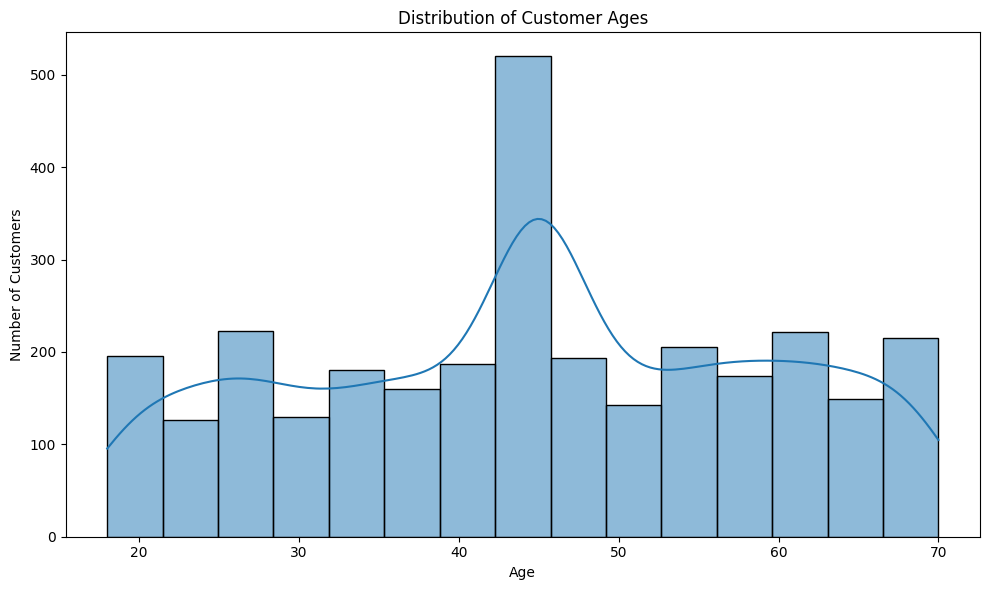

In [127]:
# Graph 1: Customer Age Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    demo_final["Age"],
    bins=15,
    kde=True
)

plt.title("Distribution of Customer Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

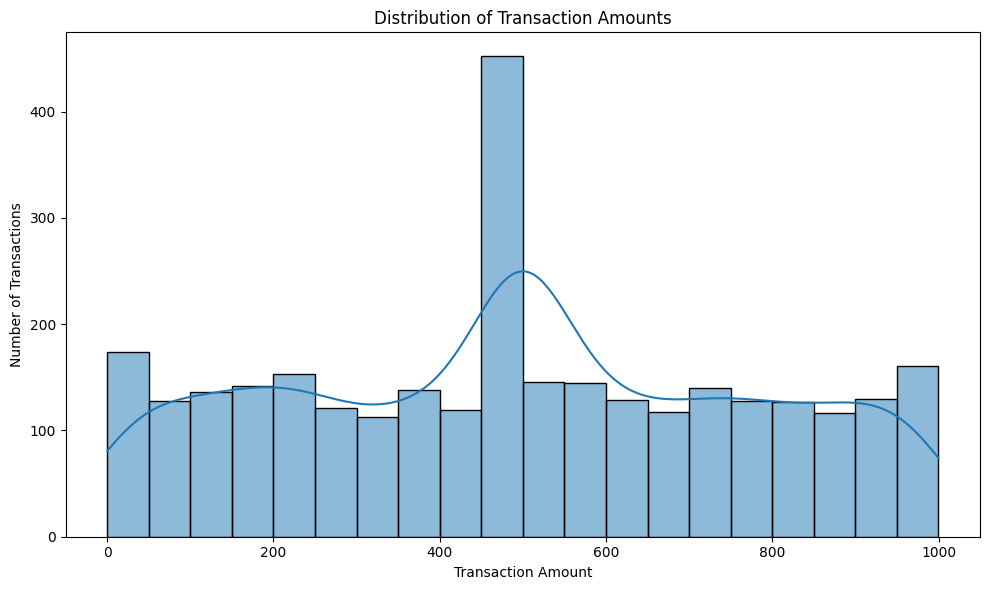

In [128]:
# Graph 2: Transaction Amount Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    trans_final["Amount"],
    bins=20,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

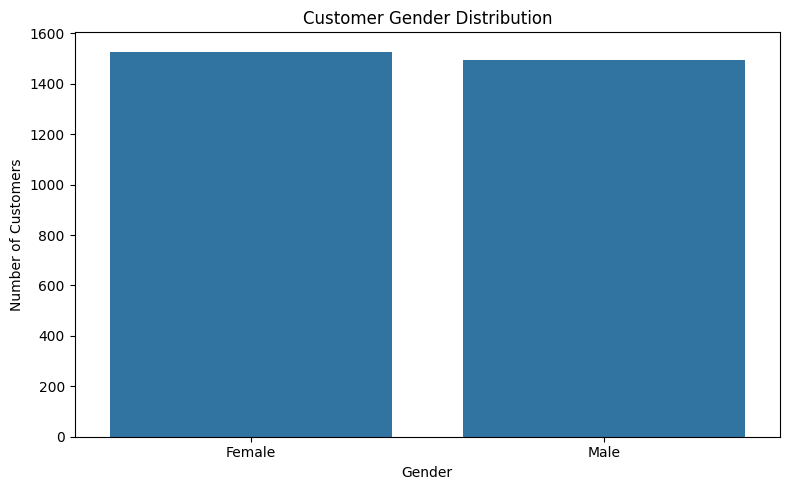

In [129]:
# Graph 3: Customer Gender Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=demo_final,
    x="Gender"
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

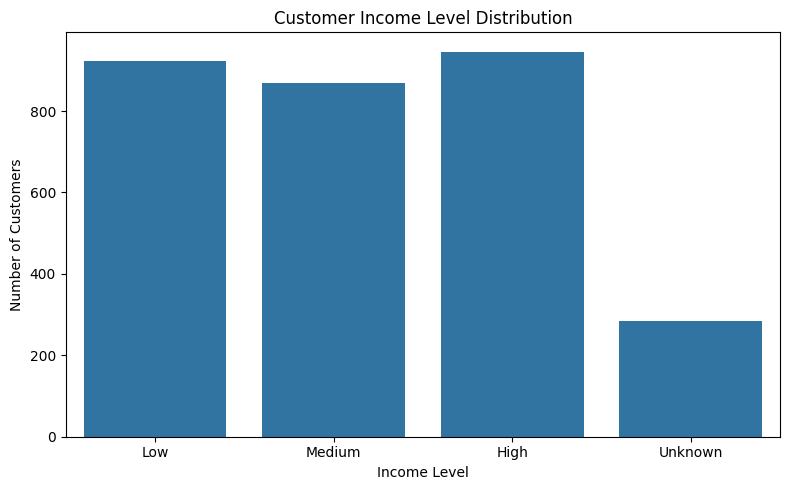

In [130]:
# Graph 4: Customer Income Level Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=demo_final,
    x="IncomeLevel",
    order=["Low", "Medium", "High", "Unknown"]
)

plt.title("Customer Income Level Distribution")
plt.xlabel("Income Level")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

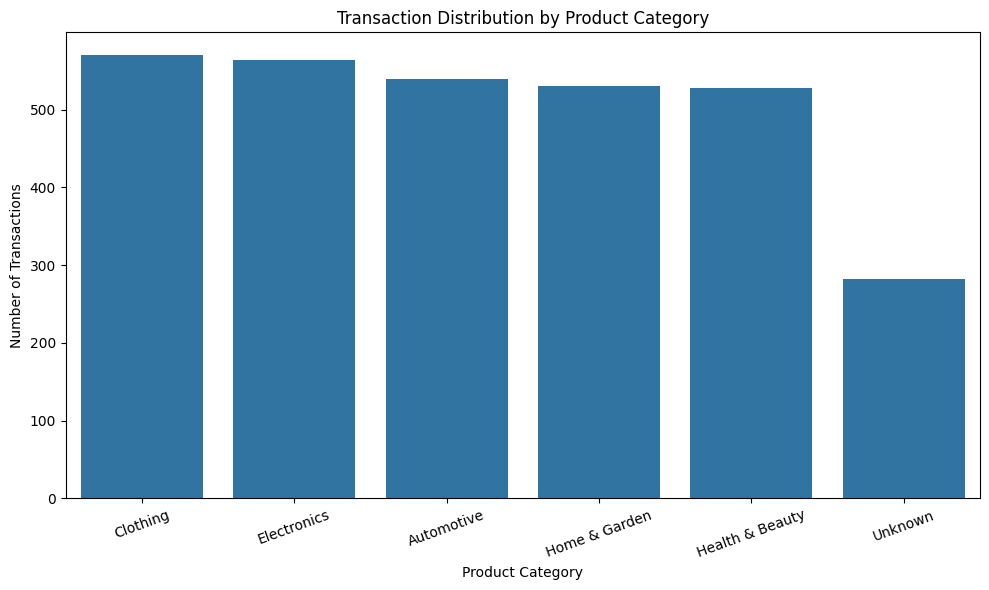

In [131]:
# Graph 5: Transaction Product Category Distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=trans_final,
    x="ProductCategory",
    order=trans_final["ProductCategory"].value_counts().index
)

plt.title("Transaction Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

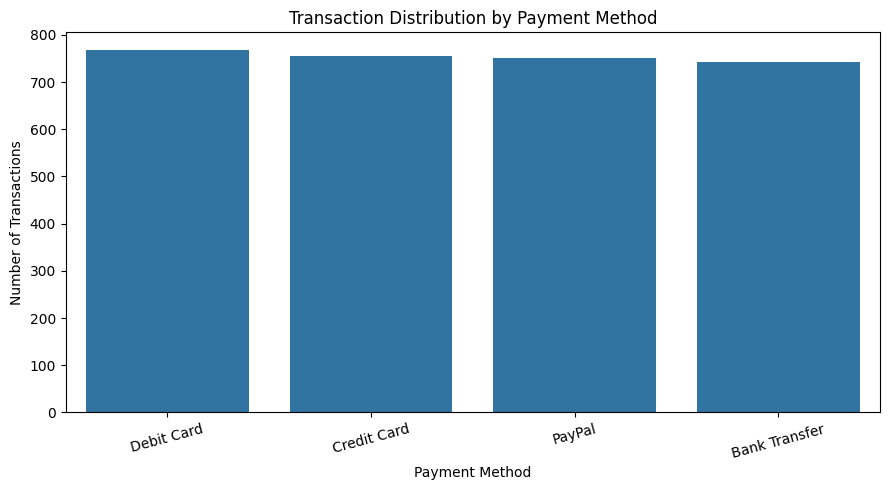

In [132]:
# Graph 6: Payment Method Distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=trans_final,
    x="PaymentMethod",
    order=trans_final["PaymentMethod"].value_counts().index
)

plt.title("Transaction Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

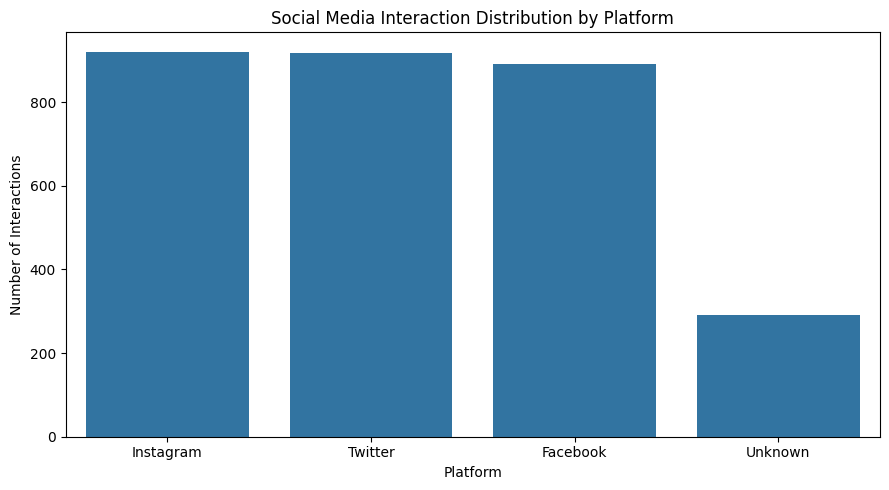

In [133]:
# Graph 7: Social Media Platform Distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=social_final,
    x="Platform",
    order=social_final["Platform"].value_counts().index
)

plt.title("Social Media Interaction Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

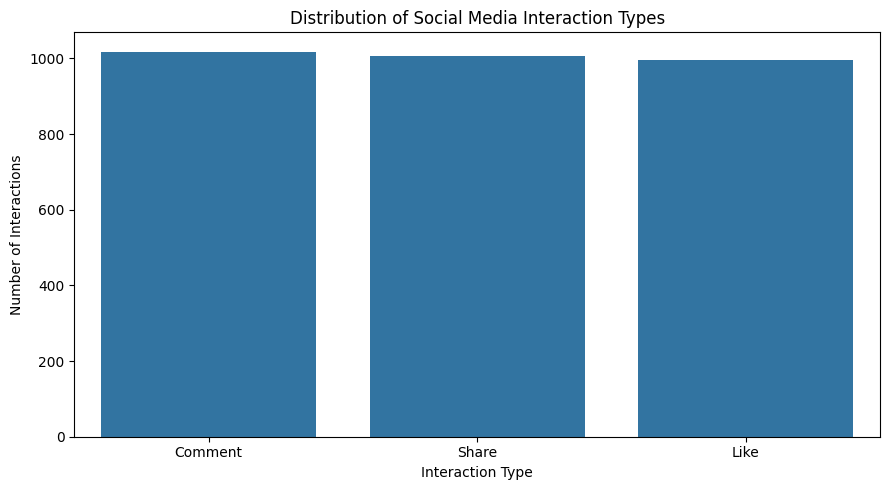

In [134]:
# Graph 8: Social Media Interaction Type Distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=social_final,
    x="InteractionType",
    order=social_final["InteractionType"].value_counts().index
)

plt.title("Distribution of Social Media Interaction Types")
plt.xlabel("Interaction Type")
plt.ylabel("Number of Interactions")
plt.tight_layout()
plt.show()

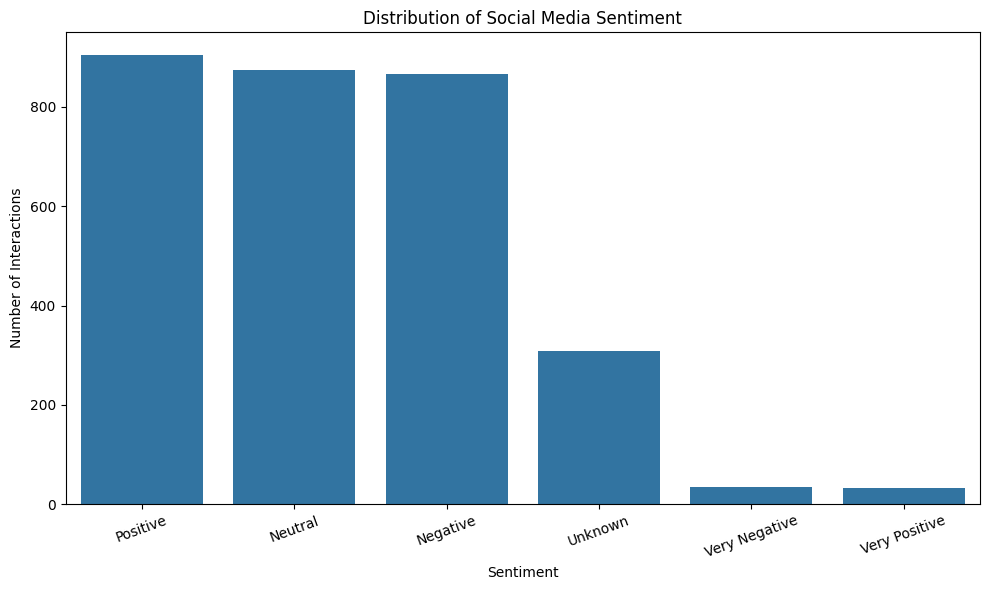

In [135]:
# Graph 9: Social Media Sentiment Distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=social_final,
    x="Sentiment",
    order=social_final["Sentiment"].value_counts().index
)

plt.title("Distribution of Social Media Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

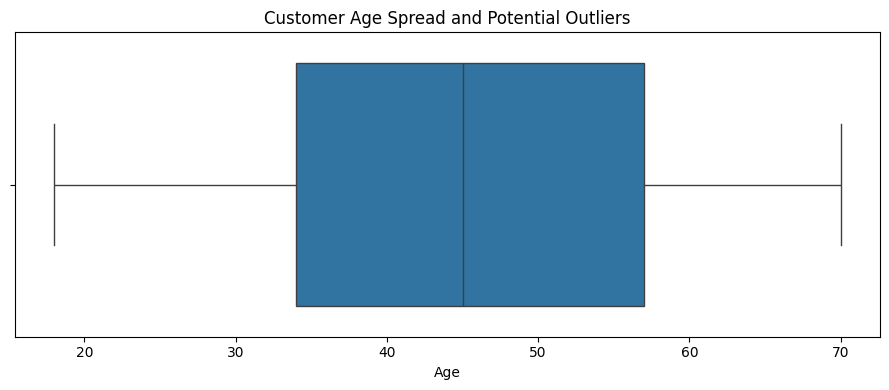

In [136]:
# Graph 10: Customer Age Boxplot

plt.figure(figsize=(9, 4))

sns.boxplot(
    x=demo_final["Age"]
)

plt.title("Customer Age Spread and Potential Outliers")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

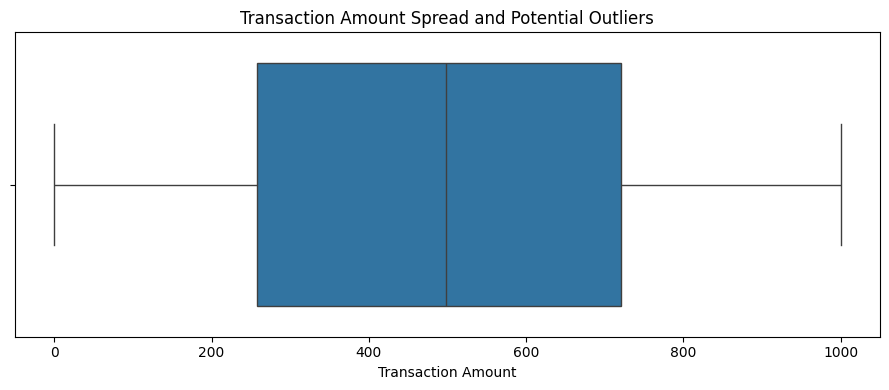

In [137]:
# Graph 11: Transaction Amount Boxplot

plt.figure(figsize=(9, 4))

sns.boxplot(
    x=trans_final["Amount"]
)

plt.title("Transaction Amount Spread and Potential Outliers")
plt.xlabel("Transaction Amount")

plt.tight_layout()
plt.show()

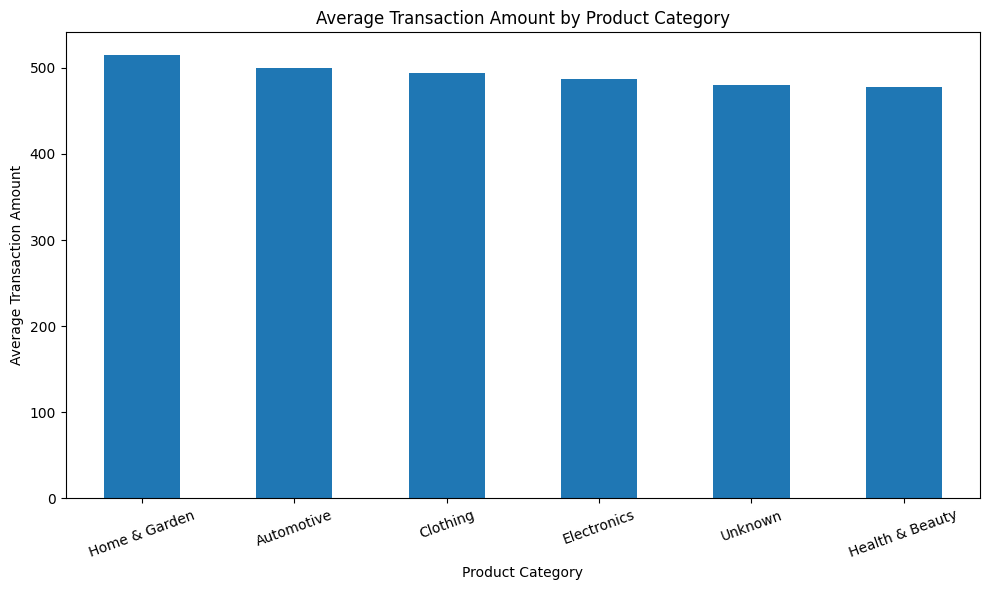

In [138]:
# Graph 12: Average Transaction Amount by Product Category

average_amount = trans_final.groupby("ProductCategory")["Amount"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

average_amount.plot(kind="bar")

plt.title("Average Transaction Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

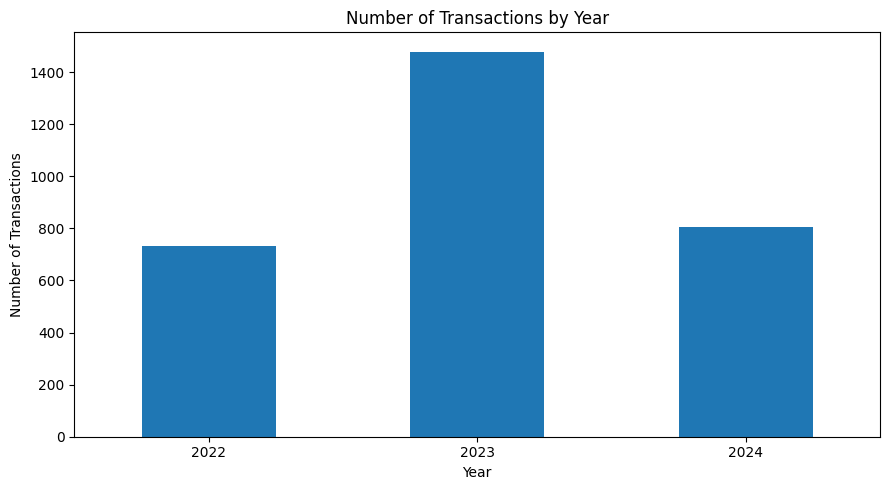

In [139]:
# Graph 13: Number of Transactions by Year

trans_final["TransactionDate"] = pd.to_datetime(trans_final["TransactionDate"])

transactions_by_year = trans_final["TransactionDate"].dt.year.value_counts().sort_index()

plt.figure(figsize=(9, 5))

transactions_by_year.plot(kind="bar")

plt.title("Number of Transactions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [140]:
# Final verification of all cleaned datasets

final_datasets = {
    "Customer Demographics": demo_final,
    "Customer Transactions": trans_final,
    "Social Media Interactions": social_final
}

for name, df in final_datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:", df.isna().sum().sum())

print("\nFinal dataset verification complete.")


Customer Demographics
Rows: 3023
Columns: 6
Duplicate rows: 0
Missing values: 0

Customer Transactions
Rows: 3015
Columns: 6
Duplicate rows: 0
Missing values: 0

Social Media Interactions
Rows: 3020
Columns: 6
Duplicate rows: 0
Missing values: 0

Final dataset verification complete.
